In [1]:
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np

import cliffordep

# turn figures from blurry png to svg
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

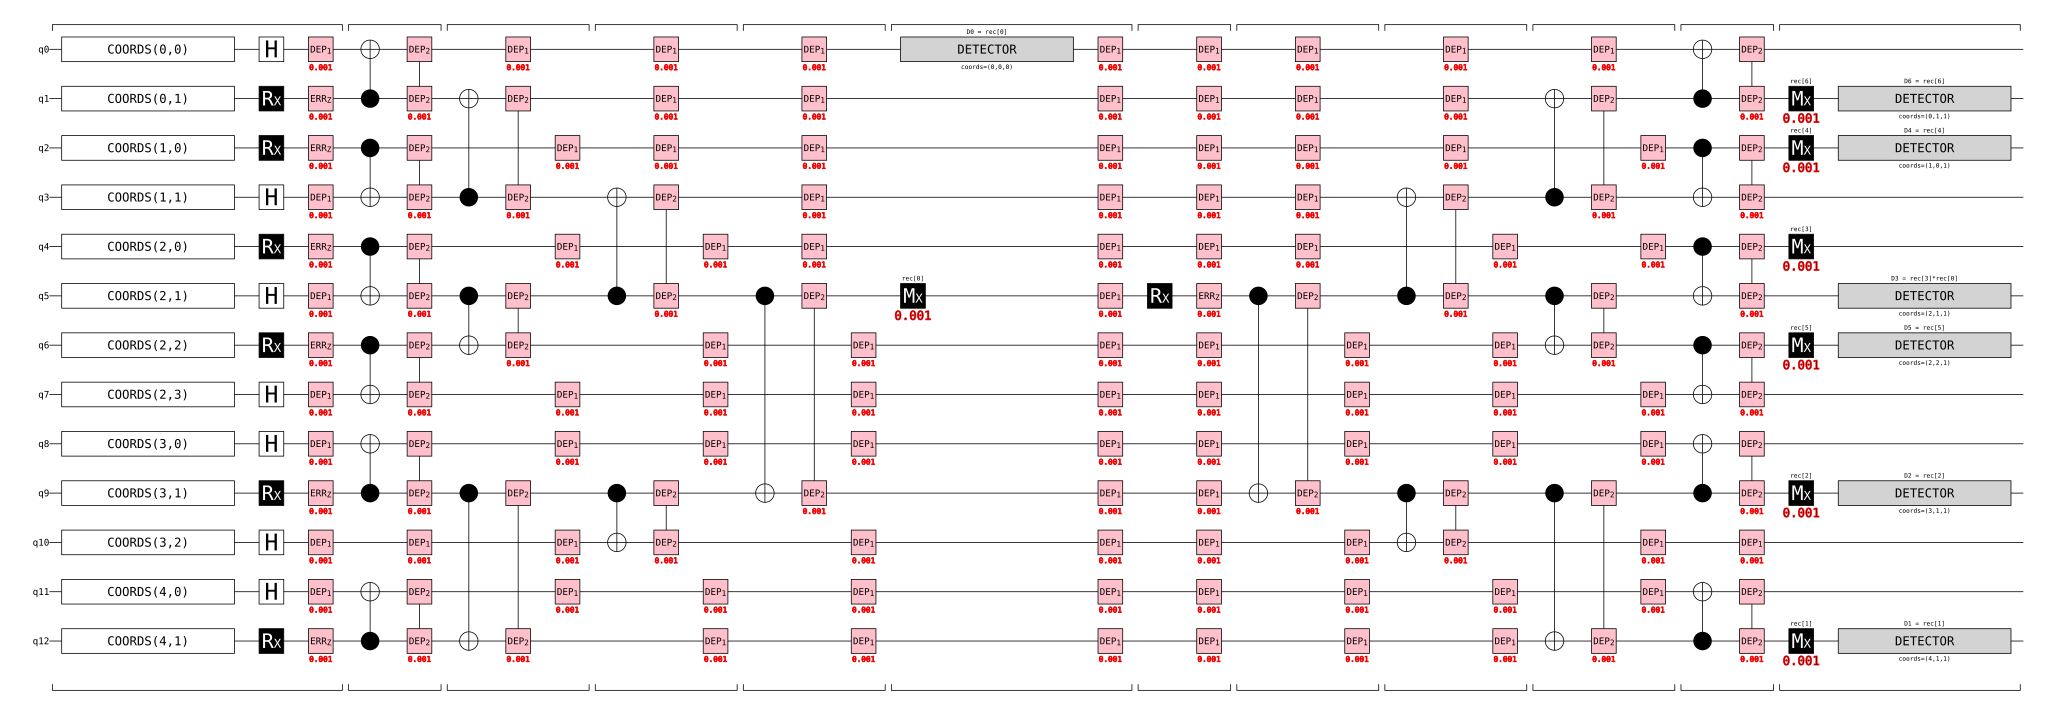

In [2]:
circuit = cliffordep.circuits.D3DoubleCatCheckA6()
noise_strength = 1e-3
noisy_circuit = cliffordep.noise.uniformly_depolarize(circuit.INNER_CIRCUIT, noise_level=noise_strength)
# remove last layer of depolarizing noise
noisy_circuit = noisy_circuit[:-1]
noisy_circuit.diagram('timeline-svg')

In [3]:
cultiv_circuit = cliffordep.CultivationCircuit(
    noisy_circuit=noisy_circuit,
    data_indices=circuit.DATA_INDICES,
    stabilizer_generators=circuit.STABILIZER_GENERATORS,
    logical_x=circuit.LOGICAL_X,
    logical_z=circuit.LOGICAL_Z,
)
combinator = cliffordep.ErrorMechanismCombinator(cultiv_circuit)

In [4]:
# takes 5 s
fault_combinations = combinator.get_undetected_mechanism_combinations(
    max_order=4,
    print_progress=True,
)

Finding undetected combinations of length 0...
Done. They lead to 1 distinct effects.
Finding undetected combinations of length 1...
Done. They lead to 32 distinct effects.
Finding undetected combinations of length 2...
Done. They lead to 413 distinct effects.
Finding undetected combinations of length 3...
Done. They lead to 2544 distinct effects.
Finding undetected combinations of length 4...
Done. They lead to 8048 distinct effects.


In [ ]:
# takes 17 s
states: list[Literal['T', 'S', 'Z']] = ['T', 'S', 'Z']
kept_strings = {state: combinator.get_kept_strings(
    fault_combinations,
    cultivated_state=state,
    print_progress=True,
) for state in states}

T state cultivation:
For order 0, 1 (0) effects are stabilized and lead to identity (error).
For order 1, 2 (0) effects are stabilized and lead to identity (error).
For order 2, 8 (4) effects are stabilized and lead to identity (error).
For order 3, 68 (65) effects are stabilized and lead to identity (error).
For order 4, 184 (180) effects are stabilized and lead to identity (error).
S state cultivation:
For order 0, 1 (0) effects are stabilized and lead to identity (error).
For order 1, 2 (0) effects are stabilized and lead to identity (error).
For order 2, 6 (0) effects are stabilized and lead to identity (error).
For order 3, 16 (24) effects are stabilized and lead to identity (error).
For order 4, 46 (64) effects are stabilized and lead to identity (error).
Z state cultivation:
For order 0, 1 (0) effects are stabilized and lead to identity (error).
For order 1, 2 (0) effects are stabilized and lead to identity (error).
For order 2, 6 (0) effects are stabilized and lead to identity 

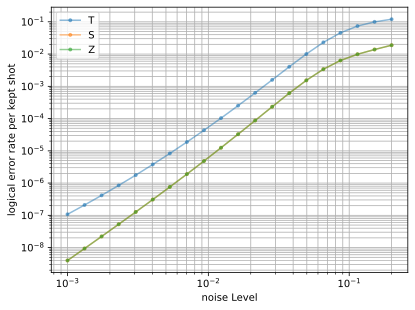

In [11]:
noise_levels = np.geomspace(1e-3, 2e-1, 20)
for state, strings in kept_strings.items():
    y = [combinator.error_rate_per_kept_shot(strings, noise_level=noise_level)
        for noise_level in noise_levels]
    plt.plot(noise_levels, y, marker='.', label=state, alpha=0.5)
plt.loglog()
plt.xlabel('noise Level')
plt.ylabel('logical error rate per kept shot')
plt.grid(True, which='both')
plt.legend()
plt.show()